# Assignment 1: Fibonacci Code Generation

Testing a language model to generate Fibonacci programs

Author: Akino  
Date: June 30, 2026

**Note:** Enable GPU in Colab (Runtime > Change runtime type > T4 GPU) to make this run faster

In [2]:
# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except:
    IN_COLAB = False
    print("Running locally")

Running in Google Colab


## 1. Install Required Packages

In [3]:
%%capture
# Install packages quietly
!pip install -q transformers torch accelerate sentencepiece
!pip install -q pandas matplotlib seaborn tqdm

print("Packages installed")

## 2. Import Libraries

In [4]:
import os
import json
import re
import time
import warnings
from datetime import datetime
from typing import Dict, List
from io import StringIO
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

print("Libraries imported")

Libraries imported


## 3. Check GPU Availability

In [5]:
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU Available: {gpu_name}")
    print(f"GPU Memory: {gpu_memory:.2f} GB")
    print("\nExperiments will run faster with GPU")
else:
    print("No GPU detected - will use CPU (slower)")
    print("To enable GPU: Runtime > Change runtime type > T4 GPU")

GPU Available: NVIDIA A100-SXM4-40GB
GPU Memory: 42.41 GB

Experiments will run faster with GPU


## 4. Configuration

In [6]:
# Expected Fibonacci values
EXPECTED_FIBONACCI = [0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89]

# Test parameters - reduced for reliability
TEMPERATURE_VALUES = [0.0, 0.3, 0.5, 0.7]  # Removed 1.0 - it can cause longer/unstable generations
TOP_P_VALUES = [0.95]
TOP_K_VALUES = [50]
TRIALS_PER_CONFIG = 2  # Reduced from 3 to 2

# Model
MODEL_ID = "Qwen/Qwen2.5-Coder-0.5B-Instruct"

# Prompts
ITERATIVE_PROMPT = """Write a Python program that computes the Fibonacci sequence using an iterative approach and prints all values less than 100.

Requirements:
- Use a loop (for or while)
- Print each Fibonacci number that is less than 100
- Start with 0 and 1
"""

RECURSIVE_PROMPT = """Write a Python program that computes the Fibonacci sequence using a recursive approach and prints all values less than 100.

Requirements:
- Define a recursive function to calculate Fibonacci numbers
- Print each Fibonacci number that is less than 100
- Start with 0 and 1
"""

print(f"Model: {MODEL_ID}")
print(f"Total experiments: {len(TEMPERATURE_VALUES) * len(TOP_P_VALUES) * TRIALS_PER_CONFIG * 2}")

Model: Qwen/Qwen2.5-Coder-0.5B-Instruct
Total experiments: 16


## 5. Load Model

Loading the model - this might take a minute or two on first run

In [7]:
print(f"Loading {MODEL_ID}...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
print("Tokenizer loaded")

dtype = torch.float16 if torch.cuda.is_available() else torch.float32
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype,
    device_map="auto",
    low_cpu_mem_usage=True
)
model.eval()

device = next(model.parameters()).device
print(f"\nModel loaded successfully on {device}")

Loading Qwen/Qwen2.5-Coder-0.5B-Instruct...


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]


Model loaded successfully on cuda:0


## 6. Helper Functions

In [8]:
import signal

def generate_code(prompt: str, temperature: float = 0.7, top_p: float = 0.9,
                  top_k: int = 50, max_new_tokens: int = 256) -> str:
    messages = [
        {"role": "system", "content": "You are a helpful programming assistant. Generate clean, correct Python code."},
        {"role": "user", "content": prompt}
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer([text], return_tensors="pt").to(device)

    gen_kwargs = dict(max_new_tokens=max_new_tokens, pad_token_id=tokenizer.eos_token_id)
    if temperature > 0:
        gen_kwargs.update(do_sample=True, temperature=temperature, top_p=top_p, top_k=top_k)
    else:
        gen_kwargs['do_sample'] = False

    with torch.no_grad():
        outputs = model.generate(**inputs, **gen_kwargs)

    start = inputs.input_ids.shape[1]
    return tokenizer.decode(outputs[0][start:], skip_special_tokens=True).strip()


def extract_python_code(text: str) -> str:
    code_block = re.search(r'```python\n(.*?)```', text, re.DOTALL)
    if code_block:
        return code_block.group(1).strip()
    code_block = re.search(r'```\n(.*?)```', text, re.DOTALL)
    if code_block:
        return code_block.group(1).strip()
    return text.strip()


def run_code_safe(code: str, timeout: int = 5) -> tuple:
    """Run code with SIGALRM timeout - actually kills infinite loops/recursion on Linux/Colab"""
    def _timeout_handler(signum, frame):
        raise TimeoutError("timed out")

    old_stdout = sys.stdout
    try:
        signal.signal(signal.SIGALRM, _timeout_handler)
        signal.alarm(timeout)
        sys.stdout = StringIO()
        exec(code, {})
        output = sys.stdout.getvalue()
        signal.alarm(0)  # cancel alarm
        sys.stdout = old_stdout
        return output, None
    except TimeoutError:
        signal.alarm(0)
        sys.stdout = old_stdout
        return None, "Timeout (infinite loop/recursion)"
    except Exception as e:
        signal.alarm(0)
        sys.stdout = old_stdout
        return None, str(e)


def validate_fibonacci_code(code: str, expected_values: List[int]) -> Dict:
    result = {'executable': False, 'correct': False, 'output': None, 'error': None, 'matches_expected': False}

    # Syntax check
    try:
        compile(code, '<string>', 'exec')
        result['executable'] = True
    except SyntaxError as e:
        result['error'] = f"SyntaxError: {e}"
        return result

    # Run with hard timeout
    output, error = run_code_safe(code, timeout=5)

    if error:
        result['error'] = error
        return result

    result['output'] = (output or '').strip()
    numbers = [int(x) for x in re.findall(r'\b\d+\b', output or '')]

    if numbers == expected_values:
        result['correct'] = True
        result['matches_expected'] = True
    elif set(numbers) == set(expected_values):
        result['correct'] = True

    return result

print("Helper functions ready (SIGALRM timeout - works on Colab/Linux)")

Helper functions ready (SIGALRM timeout - works on Colab/Linux)


## 7. Run Experiments

This will test different temperature settings for both iterative and recursive implementations.  
Takes about 5-10 minutes with GPU, longer with CPU.

In [9]:
results = []
experiments = [
    ('iterative', ITERATIVE_PROMPT),
    ('recursive', RECURSIVE_PROMPT)
]

total = len(TEMPERATURE_VALUES) * len(TOP_P_VALUES) * TRIALS_PER_CONFIG * len(experiments)
print(f"Running {total} experiments...\n")

start_time = time.time()

for idx, (impl_type, prompt) in enumerate(experiments):
    print(f"\n{'='*60}")
    print(f"Testing {impl_type.upper()} implementation ({idx+1}/2)")
    print(f"{'='*60}")

    for temp in TEMPERATURE_VALUES:
        for top_p in TOP_P_VALUES:
            for top_k in TOP_K_VALUES:
                for trial in range(TRIALS_PER_CONFIG):
                    exp_num = len(results) + 1
                    print(f"\n[{exp_num}/{total}] T={temp}, trial={trial+1}...", end=" ")

                    try:
                        gen_start = time.time()
                        generated_text = generate_code(prompt, temp, top_p, top_k)
                        generation_time = time.time() - gen_start

                        code = extract_python_code(generated_text)
                        validation = validate_fibonacci_code(code, EXPECTED_FIBONACCI)

                        results.append({
                            'implementation_type': impl_type,
                            'temperature': temp,
                            'top_p': top_p,
                            'top_k': top_k,
                            'trial': trial + 1,
                            'generated_text': generated_text,
                            'extracted_code': code,
                            'executable': validation['executable'],
                            'correct': validation['correct'],
                            'matches_expected': validation['matches_expected'],
                            'output': validation['output'],
                            'error': validation['error'],
                            'generation_time': generation_time,
                            'timestamp': datetime.now().isoformat()
                        })

                        status = "✓ CORRECT" if validation['correct'] else "✗ FAILED"
                        print(f"{status} ({generation_time:.1f}s)")

                    except Exception as e:
                        print(f"✗ ERROR: {str(e)[:50]}")
                        results.append({
                            'implementation_type': impl_type,
                            'temperature': temp,
                            'top_p': top_p,
                            'top_k': top_k,
                            'trial': trial + 1,
                            'error': str(e),
                            'executable': False,
                            'correct': False,
                            'matches_expected': False
                        })

elapsed = time.time() - start_time
print(f"\n\n{'='*60}")
print(f"COMPLETED in {elapsed/60:.1f} minutes")
print(f"Total experiments: {len(results)}")
print(f"{'='*60}")

Running 16 experiments...


Testing ITERATIVE implementation (1/2)

[1/16] T=0.0, trial=1... ✗ FAILED (8.4s)

[2/16] T=0.0, trial=2... ✗ FAILED (7.1s)

[3/16] T=0.3, trial=1... ✓ CORRECT (7.0s)

[4/16] T=0.3, trial=2... ✗ FAILED (7.3s)

[5/16] T=0.5, trial=1... ✓ CORRECT (7.2s)

[6/16] T=0.5, trial=2... ✗ FAILED (7.1s)

[7/16] T=0.7, trial=1... ✓ CORRECT (7.0s)

[8/16] T=0.7, trial=2... ✓ CORRECT (7.2s)

Testing RECURSIVE implementation (2/2)

[9/16] T=0.0, trial=1... ✗ FAILED (6.9s)

[10/16] T=0.0, trial=2... ✗ FAILED (6.9s)

[11/16] T=0.3, trial=1... ✗ FAILED (7.1s)

[12/16] T=0.3, trial=2... ✗ FAILED (7.1s)

[13/16] T=0.5, trial=1... ✗ FAILED (7.1s)

[14/16] T=0.5, trial=2... ✗ FAILED (7.1s)

[15/16] T=0.7, trial=1... ✗ FAILED (7.1s)

[16/16] T=0.7, trial=2... ✗ FAILED (7.1s)


COMPLETED in 2.5 minutes
Total experiments: 16


## 8. Setup Output Folders

In [10]:
os.makedirs('results', exist_ok=True)
os.makedirs('results/iterative_outputs', exist_ok=True)
os.makedirs('results/recursive_outputs', exist_ok=True)
os.makedirs('report/figures', exist_ok=True)
print("Folders created")

Folders created


## 9. Save Results

In [11]:
# Save JSON
with open('results/analysis.json', 'w') as f:
    json.dump(results, f, indent=2)
print("Saved analysis.json")

# Save individual code samples
for result in results:
    if 'extracted_code' in result:
        impl_type = result['implementation_type']
        filename = f"temp_{result['temperature']}_trial_{result['trial']}.py"
        filepath = f"results/{impl_type}_outputs/{filename}"

        with open(filepath, 'w') as f:
            f.write(f"# Temperature: {result['temperature']}\n")
            f.write(f"# Top-p: {result['top_p']}\n")
            f.write(f"# Executable: {result['executable']}\n")
            f.write(f"# Correct: {result['correct']}\n")
            f.write(f"# Exact Match: {result['matches_expected']}\n\n")
            f.write(result['extracted_code'])

print(f"Saved {len(results)} code samples")

Saved analysis.json
Saved 16 code samples


## 10. Analyze Results

In [12]:
df = pd.DataFrame(results)

print("=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)
print(f"Total experiments: {len(df)}")
print(f"\nOverall:")
print(f"  Executable: {df['executable'].mean():.1%}")
print(f"  Correct: {df['correct'].mean():.1%}")
print(f"  Exact match: {df['matches_expected'].mean():.1%}")

print(f"\nBy Implementation:")
print(df.groupby('implementation_type')[['executable', 'correct', 'matches_expected']].mean().round(3))

print(f"\nBy Temperature:")
print(df.groupby('temperature')[['executable', 'correct', 'matches_expected']].mean().round(3))

print(f"\nAverage time: {df['generation_time'].mean():.2f}s per generation")
print("=" * 60)

RESULTS SUMMARY
Total experiments: 16

Overall:
  Executable: 100.0%
  Correct: 25.0%
  Exact match: 25.0%

By Implementation:
                     executable  correct  matches_expected
implementation_type                                       
iterative                   1.0      0.5               0.5
recursive                   1.0      0.0               0.0

By Temperature:
             executable  correct  matches_expected
temperature                                       
0.0                 1.0     0.00              0.00
0.3                 1.0     0.25              0.25
0.5                 1.0     0.25              0.25
0.7                 1.0     0.50              0.50

Average time: 7.17s per generation


## 11. Create Visualizations

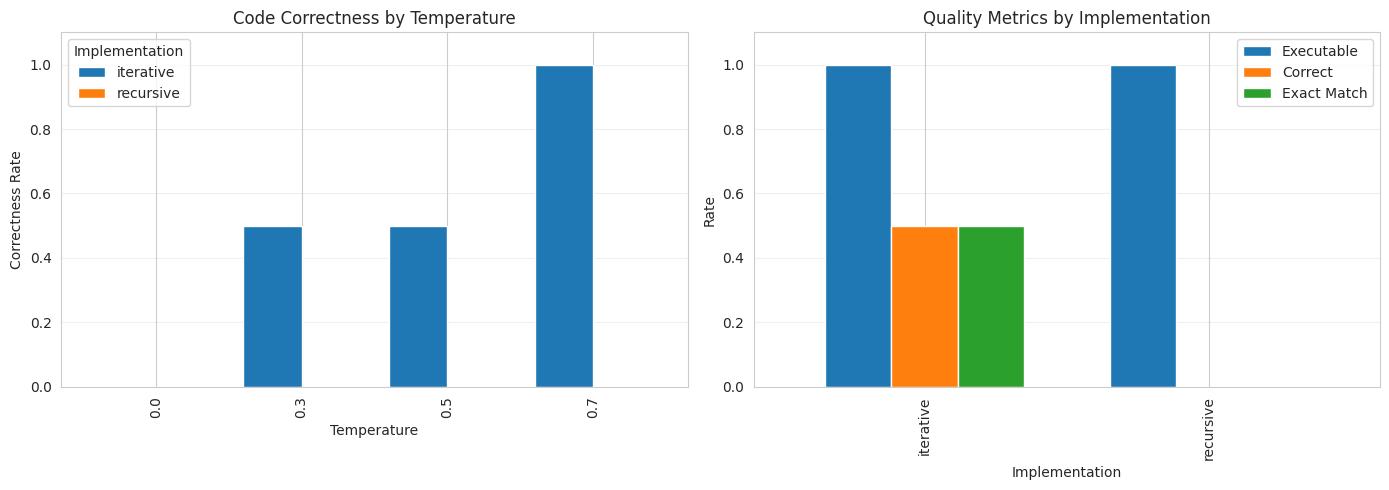

Saved analysis_overview.png


In [13]:
# Chart 1: Correctness by temperature
success_by_temp = df.groupby(['temperature', 'implementation_type'])['correct'].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

success_by_temp.plot(kind='bar', ax=axes[0], width=0.8)
axes[0].set_title('Code Correctness by Temperature')
axes[0].set_xlabel('Temperature')
axes[0].set_ylabel('Correctness Rate')
axes[0].set_ylim([0, 1.1])
axes[0].legend(title='Implementation')
axes[0].grid(axis='y', alpha=0.3)

comparison = df.groupby('implementation_type')[['executable', 'correct', 'matches_expected']].mean()
comparison.plot(kind='bar', ax=axes[1], width=0.7)
axes[1].set_title('Quality Metrics by Implementation')
axes[1].set_xlabel('Implementation')
axes[1].set_ylabel('Rate')
axes[1].set_ylim([0, 1.1])
axes[1].legend(['Executable', 'Correct', 'Exact Match'])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('report/figures/analysis_overview.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved analysis_overview.png")

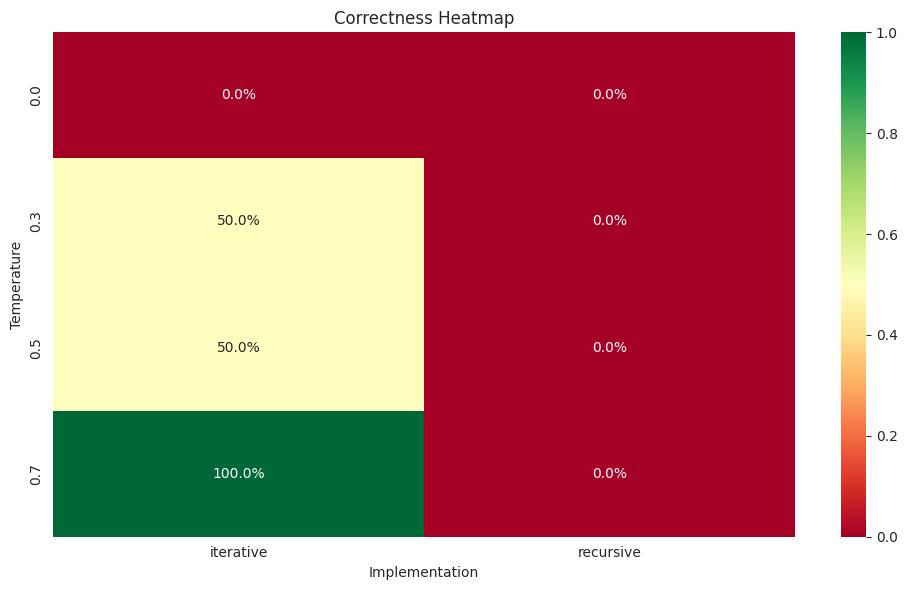

Saved correctness_heatmap.png


In [14]:
# Chart 2: Heatmap
pivot = df.pivot_table(values='correct', index='temperature', columns='implementation_type', aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.1%', cmap='RdYlGn', vmin=0, vmax=1)
plt.title('Correctness Heatmap')
plt.xlabel('Implementation')
plt.ylabel('Temperature')
plt.tight_layout()
plt.savefig('report/figures/correctness_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved correctness_heatmap.png")

## 12. Find Best Settings

In [15]:
successful = df[df['matches_expected'] == True]

if len(successful) > 0:
    print("Best Configurations:\n")
    best = successful.groupby(['implementation_type', 'temperature', 'top_p']).size().reset_index(name='successes')
    best = best.sort_values('successes', ascending=False)
    print(best.head(10))

    top = best.iloc[0]
    print(f"\nBest overall:")
    print(f"  {top['implementation_type']} with T={top['temperature']}, top_p={top['top_p']}")
    print(f"  Success rate: {top['successes']}/{TRIALS_PER_CONFIG}")
else:
    print("No perfect matches found")

Best Configurations:

  implementation_type  temperature  top_p  successes
2           iterative          0.7   0.95          2
0           iterative          0.3   0.95          1
1           iterative          0.5   0.95          1

Best overall:
  iterative with T=0.7, top_p=0.95
  Success rate: 2/2


## 13. Example Generated Code

In [16]:
if len(successful) > 0:
    print("Example: Successful Iterative\n" + "="*60)
    iter_ex = successful[successful['implementation_type'] == 'iterative'].iloc[0] if len(successful[successful['implementation_type'] == 'iterative']) > 0 else None
    if iter_ex is not None:
        print(f"Config: T={iter_ex['temperature']}, top_p={iter_ex['top_p']}\n")
        print(iter_ex['extracted_code'])
        print(f"\nOutput: {iter_ex['output']}")

    print("\n\nExample: Successful Recursive\n" + "="*60)
    rec_ex = successful[successful['implementation_type'] == 'recursive'].iloc[0] if len(successful[successful['implementation_type'] == 'recursive']) > 0 else None
    if rec_ex is not None:
        print(f"Config: T={rec_ex['temperature']}, top_p={rec_ex['top_p']}\n")
        print(rec_ex['extracted_code'])
        print(f"\nOutput: {rec_ex['output']}")

Example: Successful Iterative
Config: T=0.3, top_p=0.95

def fibonacci_sequence():
    a, b = 0, 1
    while a < 100:
        print(a)
        a, b = b, a + b

# Call the function to compute the Fibonacci sequence
fibonacci_sequence()

Output: 0
1
1
2
3
5
8
13
21
34
55
89


Example: Successful Recursive


## 14. Download Results

Creates a ZIP file and downloads it

In [17]:
if IN_COLAB:
    import shutil
    print("Creating ZIP file...")
    shutil.make_archive('assignment_1_results', 'zip', '.')

    from google.colab import files
    files.download('assignment_1_results.zip')
    print("\nDownloaded! Extract this in your assignment_1 folder")
else:
    print("Results saved locally in results/ folder")

Creating ZIP file...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Downloaded! Extract this in your assignment_1 folder


## 15. Summary for Report

In [18]:
print("Stats for LaTeX report:\n")
print("Overall:")
print(f"  Executable: {df['executable'].mean():.1%}")
print(f"  Correct: {df['correct'].mean():.1%}")
print(f"  Exact: {df['matches_expected'].mean():.1%}")

print("\nBy implementation:")
for impl in ['iterative', 'recursive']:
    subset = df[df['implementation_type'] == impl]
    print(f"\n{impl}:")
    print(f"  Executable: {subset['executable'].mean():.1%}")
    print(f"  Correct: {subset['correct'].mean():.1%}")
    print(f"  Exact: {subset['matches_expected'].mean():.1%}")

print("\nBy temperature:")
print(df.groupby('temperature')[['correct', 'generation_time']].agg(['mean', 'std']).round(3))

Stats for LaTeX report:

Overall:
  Executable: 100.0%
  Correct: 25.0%
  Exact: 25.0%

By implementation:

iterative:
  Executable: 100.0%
  Correct: 50.0%
  Exact: 50.0%

recursive:
  Executable: 100.0%
  Correct: 0.0%
  Exact: 0.0%

By temperature:
            correct        generation_time       
               mean    std            mean    std
temperature                                      
0.0            0.00  0.000           7.326  0.710
0.3            0.25  0.500           7.138  0.122
0.5            0.25  0.500           7.120  0.080
0.7            0.50  0.577           7.086  0.102


## Done

Next steps:
1. Download the ZIP (should have already happened)
2. Extract to assignment_1 folder
3. Update report.tex with the numbers above
4. Compile PDF
5. Submit